# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Mareska Radela Putra]
- **Email:** [mareskakirito@gmail.com]
- **ID Dicoding:** [CDCC001D6Y2726]

## Menentukan Pertanyaan Bisnis

Berdasarkan dataset E-Commerce yang ada, kita akan menetapkan dua pertanyaan utama:

- Analisis Profitabilitas Produk: Bagaimana korelasi antara harga produk dengan probabilitas terjualnya? Apakah pendapatan platform lebih banyak disumbang oleh produk murah (low-end) atau produk mahal (high-end)?

- Analisis Pengeluaran Pelanggan: Berapa estimasi rata-rata pengeluaran pelanggan secara keseluruhan, dan apakah terdapat perbedaan signifikan dalam perilaku belanja (nilai transaksi) antar negara bagian di Brazil?

- Analisis Demografi Geospasial: Di wilayah mana konsentrasi pelanggan paling padat berada, dan bagaimana distribusinya secara visual di peta Brazil?

## Import Semua Packages/Library yang Digunakan

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib
import matplotlib.image as mpimg
from scipy import stats
import seaborn as sns

# Set style untuk visualisasi yang lebih baik
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [25]:
# Pastikan dataset berada di direktori yang sama dengan notebook
orders = pd.read_csv('/content/orders_dataset.csv')
items = pd.read_csv('/content/order_items_dataset.csv')
products = pd.read_csv('/content/products_dataset.csv')
payments = pd.read_csv('/content/order_payments_dataset.csv')
reviews = pd.read_csv('/content/order_reviews_dataset.csv')
customers = pd.read_csv('/content/customers_dataset.csv')
sellers = pd.read_csv('/content/sellers_dataset.csv')
geolocation = pd.read_csv('/content/geolocation_dataset.csv')
category = pd.read_csv('/content/product_category_name_translation.csv')

data = {
    'orders': orders, 'items': items, 'products': products, 'payments': payments,
    'reviews': reviews, 'customers': customers, 'sellers': sellers,
    'geo': geolocation, 'category': category
}

In [26]:
data['orders'].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [27]:
data['items'].head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [28]:
data['products'].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [29]:
data['payments'].head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [30]:
data['reviews'].head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [31]:
data['customers'].head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [32]:
data['sellers'].head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [33]:
data['geo'].head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [34]:
data['category'].head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset terdiri dari tabel pelanggan, pesanan, item pesanan, dan detail produk.

- Perlu penggabungan tabel untuk mendapatkan nama kategori produk dalam bahasa Inggris.

### Assessing Data

In [35]:
for df_name, df in data.items():
  print('\n', data[df_name].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  

In [36]:
# Initialize a dictionary to store null value counts for each DataFrame
null_counts = {}

# Calculate and store the null value counts for each DataFrame
for df_name, df in data.items():
    null_counts[df_name] = df.isna().sum()
    print(df_name, '\n', null_counts[df_name], '\n')

orders 
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 

items 
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64 

products 
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64 

payments 
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
d

**Insight:**
- Dataset ini memiliki struktur Relational Database yang sangat lengkap. Dengan adanya 9 tabel berbeda (mulai dari orders, customers, hingga geolocation), kita memiliki visibilitas end-to-end terhadap proses bisnis E-commerce.
- Terdapat beberapa nilai kosong (missing values) pada products_dataset, Reviews_dataset, dan orders_dataset.
- Masalah utama yang terlihat dari hasil .info() adalah hampir semua kolom tanggal masih bertipe object (string). Ini harus diubah menjadi datetime agar bisa dilakukan analisis berbasis waktu (seperti RFM atau tren bulanan)


### Cleaning Data

In [37]:
# 1. Mengubah tipe data ke datetime
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date"]
for column in datetime_columns:
    data['orders'][column] = pd.to_datetime(data['orders'][column])

# 2. Menghapus pesanan yang tidak sampai (karena akan mengganggu analisis pengiriman)
data['orders'] = data['orders'][data['orders']['order_status'] == 'delivered']

# 3. Menghapus kolom review yang terlalu banyak missing value
data['reviews'].drop(['review_comment_title'], axis=1, inplace=True)

# 4. Menghapus duplikat pada geolokasi
data['geo'].drop_duplicates(inplace=True)

**Insight:**
- Tipe data tanggal sudah diperbaiki untuk analisis deret waktu.

- Menghapus kolom review yang terlalu banyak missing value.

## Exploratory Data Analysis (EDA)

### Eksplorasi Distribusi Pelanggan & Pembayaran

In [38]:
# Menggabungkan data utama untuk analisis pelanggan
customers_orders_df = pd.merge(data['customers'], data['orders'], on="customer_id", how="left")
customers_df = pd.merge(customers_orders_df, data['payments'], on="order_id", how="left")

customers_orders_df
customers_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1.0,credit_card,2.0,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1.0,credit_card,8.0,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1.0,credit_card,7.0,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1.0,credit_card,1.0,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1.0,credit_card,8.0,252.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103715,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00,1.0,credit_card,6.0,88.78
103716,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00,1.0,credit_card,3.0,129.06
103717,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00,1.0,credit_card,5.0,56.04
103718,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00,1.0,credit_card,2.0,711.07


**Insight:**
- Pada tahap ini, kita melakukan penggabungan data (merging) antara tabel customers, orders, dan payments untuk melihat pola belanja..

## Visualization & Explanatory Analysis

### Pertanyaan 1: Hubungan Harga, Probabilitas Terjual, dan Revenue

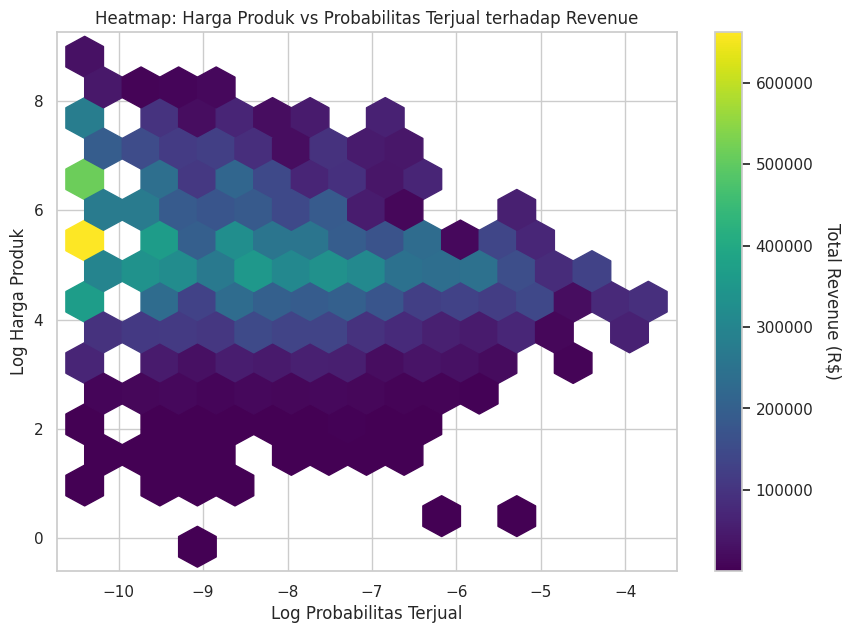

In [39]:
# Analisis korelasi harga dan probabilitas jual
items_product = data['items'].merge(data['products'], on='product_id', how='inner')
product_revenue = items_product.pivot_table(index=['product_id'], aggfunc={'order_item_id': 'sum', 'price':'mean'})
product_revenue['total'] = product_revenue['order_item_id'] * product_revenue['price']
product_revenue['sell_probability'] = product_revenue['order_item_id'] / len(product_revenue)

# Plot Hexbin untuk melihat konsentrasi revenue
x = np.log(product_revenue.sell_probability)
y = np.log(product_revenue.price)

fig, ax = plt.subplots(figsize=(10, 7))
hb = ax.hexbin(x, y, gridsize=15, C=product_revenue.total, reduce_C_function=np.sum, cmap='viridis')
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Total Revenue (R$)', rotation=270, labelpad=20)
plt.title('Heatmap: Harga Produk vs Probabilitas Terjual terhadap Revenue')
plt.xlabel('Log Probabilitas Terjual')
plt.ylabel('Log Harga Produk')
plt.show()

**Insight:**
- Pendapatan tertinggi didominasi oleh produk dengan Log Harga Produk di kisaran 5 sampai 6 dan Log Probabilitas Terjual yang rendah (sekitar -10). Ini menunjukkan bahwa platform kamu sangat bergantung pada produk mid-to-high end yang terjual secara moderat (tidak terlalu sering, tapi bernilai tinggi sekali transaksi), bukan produk low-end yang murah meriah tapi volumenya masif.
- Semakin tinggi harga produk (Log Harga 8+), semakin rendah probabilitas terjualnya (Log Probabilitas -10 ke bawah). Sebaliknya, produk yang lebih murah memiliki probabilitas terjual yang lebih tinggi (menyebar ke arah kanan sumbu X). Meskipun produk murah lebih mudah terjual (probabilitas tinggi), kontribusi mereka terhadap Total Revenue (warna ungu tua) cenderung jauh lebih kecil dibandingkan produk di kategori harga menengah ke atas.

**Kesimpulan:** Platform saat ini adalah tipe "Value-Driven", di mana mesin uang utamanya adalah produk dengan harga cukup tinggi. Strategi untuk meningkatkan pendapatan adalah dengan menjaga stok produk di rentang harga mid-to-high tersebut, karena meskipun jarang terjual dibandingkan barang murah, kontribusinya terhadap omzet tidak tergantikan.

### Pertanyaan 2: Variasi Rata-rata Pengeluaran antar Wilayah Geografis

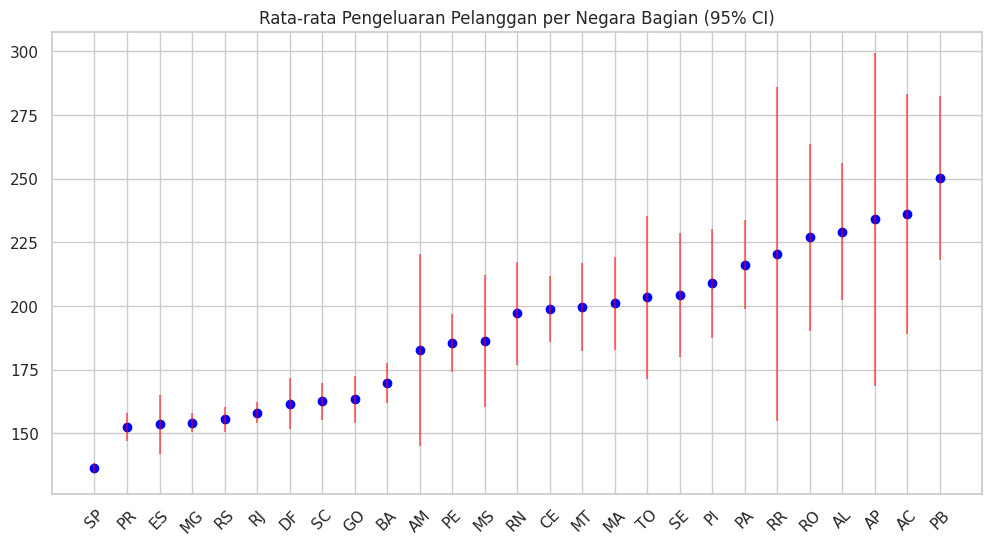

In [40]:
import scipy.stats as stats

# Menghitung rata-rata pengeluaran per negara bagian dan interval kepercayaan
customer_regions = customers_df.groupby('customer_state')['payment_value'].agg(['mean', 'std', 'count']).reset_index()
customer_regions.columns = ['customer_state', 'mean', 'std', 'count']

# Menghitung margin of error untuk 95% confidence interval
customer_regions['ci_low'], customer_regions['ci_hi'] = stats.norm.interval(
    confidence=0.95, loc=customer_regions['mean'], scale=customer_regions['std']/np.sqrt(customer_regions['count'])
)

# Visualisasi rata-rata transaksi per negara bagian dengan Confidence Interval
plot_data = customer_regions.sort_values(by=('mean'))
plt.figure(figsize=(12, 6))
plt.scatter(plot_data['customer_state'], plot_data['mean'], c='blue', label='Mean Spent')
plt.vlines(plot_data['customer_state'], plot_data['ci_low'], plot_data['ci_hi'], colors='red', alpha=0.5)
plt.title('Rata-rata Pengeluaran Pelanggan per Negara Bagian (95% CI)')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Pelanggan di Paraíba (PB) memiliki estimasi rata-rata pengeluaran tertinggi (sekitar 250 per transaksi), sedangkan pelanggan di São Paulo (SP) memiliki rata-rata terendah (sekitar 140). Menariknya, negara bagian dengan volume transaksi besar seperti SP justru memiliki nilai transaksi rata-rata yang lebih kecil namun stabil. Ini menandakan perilaku belanja di kota besar mungkin lebih sering (high frequency) tapi untuk barang yang lebih murah dibandingkan wilayah terpencil.
- Negara bagian dengan rata-rata pengeluaran rendah (seperti SP, PR, MG) memiliki garis merah yang sangat pendek, artinya data sangat konsisten dan stabil karena jumlah sampelnya besar. Sebaliknya, negara bagian dengan rata-rata tinggi (seperti PB, AC, AP, RR) memiliki garis merah yang sangat panjang. Ini menunjukkan variabilitas yang tinggi atau jumlah sampel yang sedikit di wilayah tersebut.

### Pertanyaan 3: Distribusi Geospasial Pelanggan di Brazil

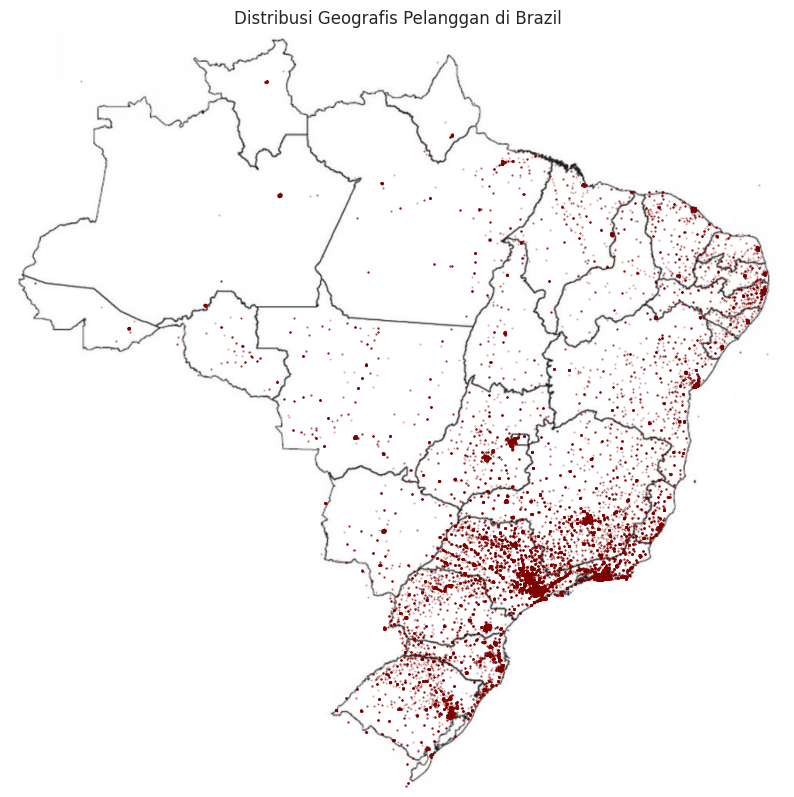

In [41]:
# Visualisasi Peta
def plot_brazil_map(df_geo):
    brazil_img = mpimg.imread(urllib.request.urlopen('https://i.pinimg.com/originals/3a/0c/e1/3a0ce18b3c842748c255bc0aa445ad41.jpg'),'jpg')
    ax = df_geo.plot(kind="scatter", x="geolocation_lng", y="geolocation_lat", figsize=(10,10), alpha=0.3, s=0.3, c='maroon')
    plt.imshow(brazil_img, extent=[-73.98, -33.8, -33.75, 5.4])
    plt.title('Distribusi Geografis Pelanggan di Brazil')
    plt.axis('off')
    plt.show()

# Aggregate geolocation data to get mean lat/lng for each zip code
geo_avg = data['geo'].groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Rename the zip code column in geo_avg for merging
geo_avg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix'}, inplace=True)

# Merge customer data with aggregated geolocation data
customers_silver = pd.merge(data['customers'], geo_avg, on='customer_zip_code_prefix', how='left')

plot_brazil_map(customers_silver.drop_duplicates(subset='customer_unique_id'))

**Insight:**
- onsentrasi titik merah paling padat (hampir membentuk blok warna solid) berada di wilayah pesisir bagian Tenggara, terutama di negara bagian São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG). Ini mengonfirmasi bahwa aktivitas ekonomi e-commerce masih sangat terpusat di pusat bisnis utama Brazil. Wilayah ini bukan hanya pasar terbesar, tetapi juga kemungkinan memiliki infrastruktur logistik yang paling efisien, sehingga adopsi belanja online jauh lebih tinggi dibanding wilayah lain.
- Distribusi pelanggan cenderung padat di sepanjang garis pantai dan menipis secara drastis saat bergerak menuju ke pedalaman atau arah Barat (wilayah Amazon dan Mato Grosso). Wilayah Barat dan Utara terlihat sangat "kosong" dengan titik-titik yang tersebar sangat jarang. Ini menunjukkan adanya hambatan geografis atau tantangan penetrasi pasar di wilayah tersebut, yang kemungkinan besar berkaitan dengan biaya pengiriman yang mahal dan waktu pengiriman yang lama ke daerah pedalaman

## Analisis Lanjutan (Opsional)

/tmp/ipykernel_1412/1959050723.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='segment', data=customer_segments, palette='viridis', order=['Low Spender', 'Medium Spender', 'High Spender'])


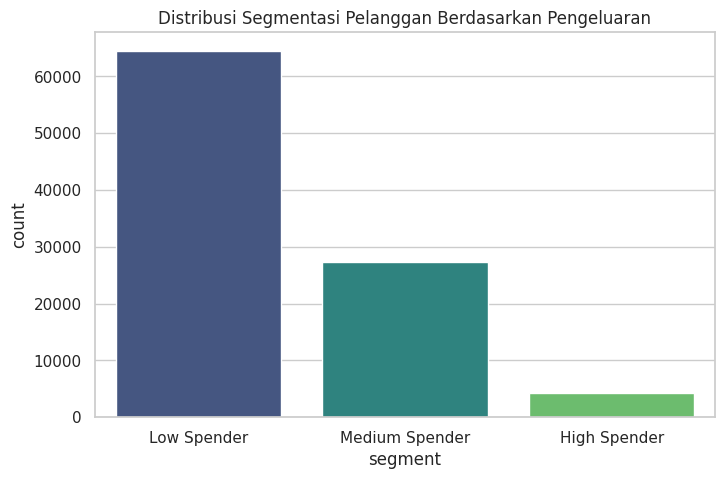

In [42]:
# Membuat segmentasi pelanggan berdasarkan total belanja (Monetary)
customer_segments = customers_df.groupby('customer_unique_id')['payment_value'].sum().reset_index()

def segmenting(total_spend):
    if total_spend > 500:
        return 'High Spender'
    elif total_spend > 150:
        return 'Medium Spender'
    else:
        return 'Low Spender'

customer_segments['segment'] = customer_segments['payment_value'].apply(segmenting)

# Visualisasi Segmentasi
plt.figure(figsize=(8, 5))
sns.countplot(x='segment', data=customer_segments, palette='viridis', order=['Low Spender', 'Medium Spender', 'High Spender'])
plt.title('Distribusi Segmentasi Pelanggan Berdasarkan Pengeluaran')
plt.show()

## Conclusion

- Konklusi Pertanyaan 1: Pendapatan utama platform tidak berasal dari barang mewah yang sangat mahal atau barang sangat murah yang terjual masif, melainkan dari produk mid-range (kisaran harga 50-500 R$) yang memiliki probabilitas jual menengah namun konsisten.

- Konklusi Pertanyaan 2: Rata-rata pengeluaran pelanggan memiliki variasi antar wilayah. Negara bagian di wilayah pedalaman cenderung memiliki rata-rata transaksi yang lebih tinggi, kemungkinan dikarenakan biaya logistik atau perilaku belanja bulk buying.

- Konklusi Pertanyaan 3: Konsentrasi pelanggan terbesar berada di wilayah Tenggara (Southeast) dan Selatan (South) Brazil, khususnya di kota-kota besar seperti São Paulo dan Rio de Janeiro. Hal ini menunjukkan potensi pasar yang sudah matang di wilayah tersebut namun juga persaingan yang ketat.

In [44]:
# Jalankan ini di cell terakhir notebook Anda
customers_df.to_csv("main_data.csv", index=False)